In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [2]:
master_df = pd.read_csv("../data/processed/master_dataset_v2.csv")
df = master_df.copy()

In [11]:
# Multiple regression: predicting real_income_pc from multiple predictors
predictors = ['income_pc','employment_pc','gdp_pc', 'rpp']
X = df[predictors]
y = df['real_income_pc']

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         real_income_pc   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     2215.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:58:05   Log-Likelihood:                -7946.1
No. Observations:                 867   AIC:                         1.590e+04
Df Residuals:                     862   BIC:                         1.593e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.597e+04   1485.462     17.482

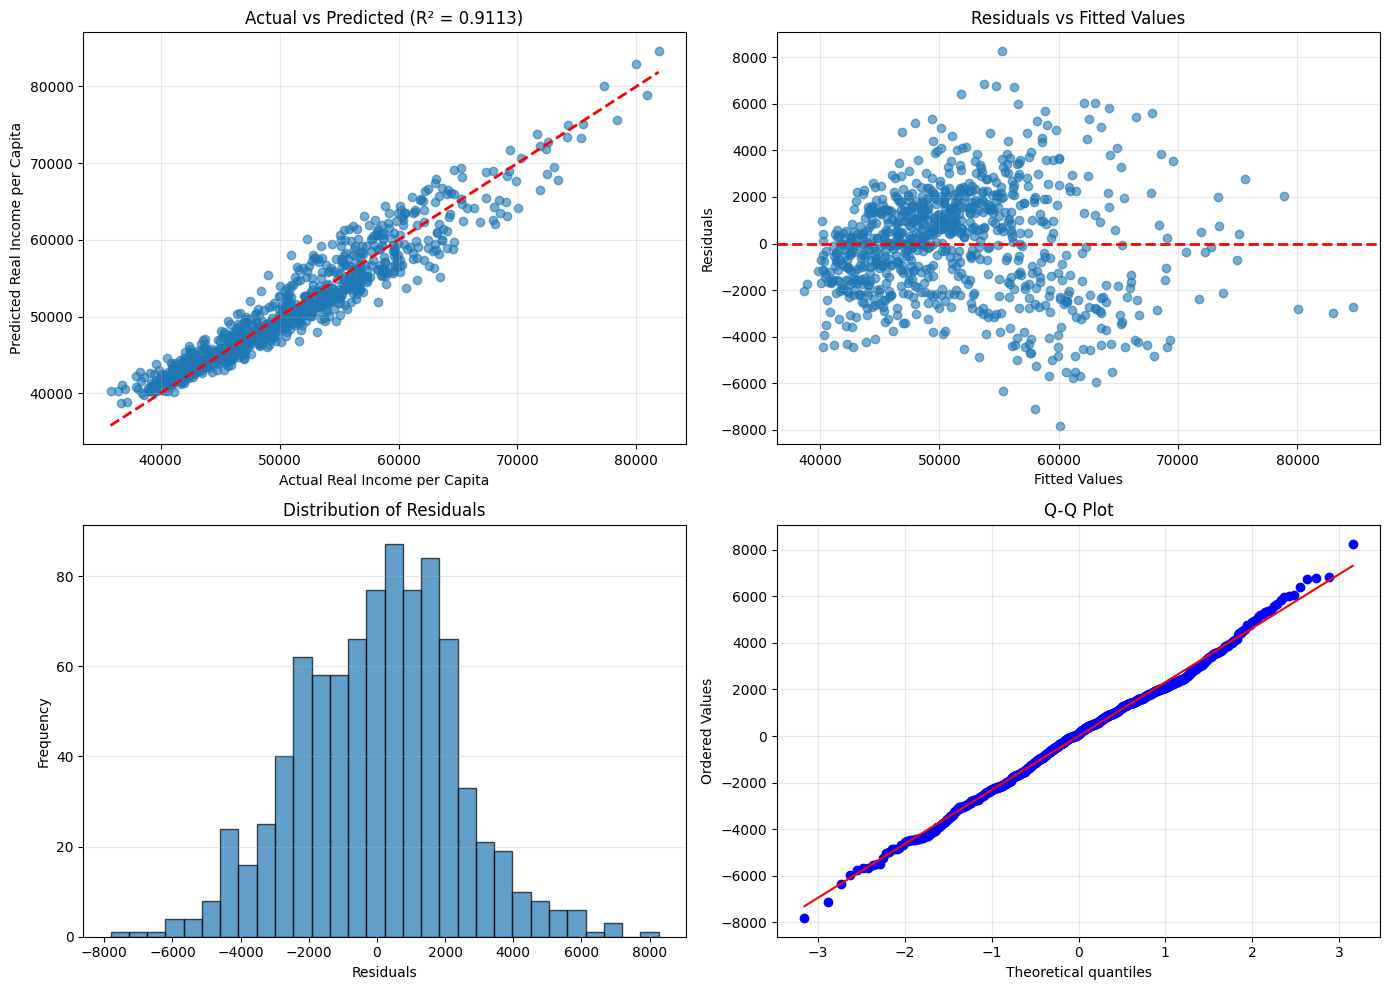


Model Performance:
R-squared: 0.9113
Adjusted R-squared: 0.9109
F-statistic: 2214.8103
Prob (F-statistic): 0.0000e+00


In [5]:
# Visualizations and diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted
predictions = model.predict(X)
axes[0, 0].scatter(y, predictions, alpha=0.6)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Real Income per Capita')
axes[0, 0].set_ylabel('Predicted Real Income per Capita')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {model.rsquared:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# Residuals vs Fitted
residuals = model.resid
axes[0, 1].scatter(predictions, residuals, alpha=0.6)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].grid(True, alpha=0.3)

# Histogram of Residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel Performance:")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.4f}")
print(f"Prob (F-statistic): {model.f_pvalue:.4e}")